# Sparse Random Projections — Machine Learning Assignment 1

## Overview

In this notebook, we implement **Sparse Random Projections (Sparse RP)** to perform dimensionality reduction. Our primary goal is to evaluate how classification accuracy changes as a function of the number of retained dimensions $k$ compared to the original dimension $d$.

We analyze the performance across **two datasets** with distinct characteristics:
* **Dataset A (20 Newsgroups Vectorized)** — A text dataset characterized by highly dimensional, sparse, non-Euclidean feature spaces.
* **Dataset B (Fashion MNIST)** — An image dataset with a moderate number of dense, Euclidean dimensions.

## Key Design Choices
1. Fixed train/test split to ensure a fair comparison across all projected dimensions.
2. The projection matrix is fitted *only* on the training data to prevent data leakage.
3. An ensemble approach averaging over multiple random seeds (runs) per dimension $k$ to suppress variance and noise.
4. Appropriate baseline classifiers (Linear SVC for text, KNN for images) to evaluate the relative loss or gain in accuracy.
5. Unprojected baseline performance is plotted as a dashed reference line.

In [75]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
from joblib import Parallel, delayed
from sklearn import metrics
from sklearn.datasets import fetch_20newsgroups_vectorized
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.random_projection import johnson_lindenstrauss_min_dim, SparseRandomProjection
from sklearn.svm import LinearSVC
from tensorflow.keras.datasets import fashion_mnist

# Suppress convergence warnings from LinearSVC for cleaner output during experimentation
warnings.filterwarnings('ignore')

## Core Functions

This section defines the utility functions for our experiment. To ensure the code runs efficiently, we utilize `joblib.Parallel` to distribute the independent random projection trials across multiple CPU cores.

We define separate worker functions for the Support Vector Classifier (SVC) and K-Nearest Neighbors (KNN) because they require slightly different hyperparameters to converge efficiently on varying dimensionalities.

In [76]:
def compute_baseline_accuracy(given_model, train_data, train_target, test_data, test_target):
    """
    Trains a classifier on full-dimensional data and computes the accuracy.
    This establishes a baseline for comparison with dimensionality reduction methods.
    """
    model = given_model()
    model.fit(train_data, train_target)
    predictions = model.predict(test_data)
    return metrics.accuracy_score(test_target, predictions)


def _single_svc_task(train_data, train_target, test_data, test_target, dim):
    """Execution unit for one dimension and one random run using LinearSVC."""
    # 1. Initialize and apply Sparse Random Projection
    projection = SparseRandomProjection(n_components=dim)

    # Fit ONLY on training data to prevent data leakage, then transform both
    xtr = projection.fit_transform(train_data)
    xte = projection.transform(test_data)

    # 2. LinearSVC Optimization
    # 'dual=False' is preferred when n_samples > n_features (typical for Random Projections)
    # 'tol=1e-3' and 'max_iter=2000' prevent hanging on slow convergence in lower dimensions
    model = LinearSVC(dual=False, max_iter=2000, tol=1e-3)
    model.fit(xtr, train_target)
    print(f'Finished processing SVC for dimension: {dim}')

    return model.score(xte, test_target)


def evaluate_svc_projections_final(train_data, train_target, test_data, test_target, dimensions, n_runs=10, n_jobs=-1):
    """Executes a parallel ensemble of n_runs per dimension for the Linear SVC task."""
    # n_jobs=-1 utilizes all available CPU logical cores
    flat_results = Parallel(n_jobs=n_jobs)(
        delayed(_single_svc_task)(train_data, train_target, test_data, test_target, d)
        for d in dimensions for _ in range(n_runs)
    )

    # Reshape the 1D list into a matrix of shape (number_of_dimensions, n_runs)
    results_matrix = np.array(flat_results).reshape(len(dimensions), n_runs)

    # Return the average accuracy across all runs for each dimension
    return results_matrix.mean(axis=1)


def _evaluate_single_instance(train_data, train_target, test_data, test_target, dim):
    """Worker function for one specific dimension and one run using KNN."""
    # 1. Project the data
    projection = SparseRandomProjection(n_components=dim)
    projected_train = projection.fit_transform(train_data)
    projected_test = projection.transform(test_data)

    # 2. KNN Logic
    model = KNeighborsClassifier(n_neighbors=5, algorithm='auto')
    model.fit(projected_train, train_target)
    print(f'Finished processing KNN for dimension: {dim}')

    return model.score(projected_test, test_target)


def evaluate_knn_projections_final(train_data, train_target, test_data, test_target, dimensions, n_runs=10, n_jobs=-1):
    """Executes a parallel ensemble of n_runs per dimension for the KNN task."""
    all_accuracies = Parallel(n_jobs=n_jobs)(
        delayed(_evaluate_single_instance)(train_data, train_target, test_data, test_target, d)
        for d in dimensions for _ in range(n_runs)
    )

    results_matrix = np.array(all_accuracies).reshape(len(dimensions), n_runs)
    return results_matrix.mean(axis=1)


def plot_projection_performance(ax, k_vals, means, baseline, d, title="Projection Performance", color="#2c7fb8"):
    """
    Plots the mean accuracy curve for random projections against the full-dimensional baseline.
    """
    k_arr = np.array(k_vals)

    # Mean accuracy curve
    ax.plot(k_arr, means, 'o-', color=color, linewidth=2.2, markersize=6, label="Mean accuracy (seeds)", zorder=3)

    # Baseline horizontal line
    ax.axhline(baseline, color='crimson', linestyle='--', linewidth=1.6, label=f"Baseline (d={d}): {baseline:.3f}",
               zorder=2)

    # Annotate the point where accuracy recovers to 97% of the baseline
    recovery_thresh = 0.97 * baseline
    for k, m in zip(k_vals, means):
        if m >= recovery_thresh:
            label_txt = f'97% recovery @ k={k}'
            ax.annotate(label_txt, xy=(k, m),
                        xytext=(k + max(k_vals) * -0.07, m - 0.02),
                        arrowprops=dict(arrowstyle='->', color='gray', lw=1.2),
                        fontsize=8.5, color='gray')
            break

    # Styling and limits
    ax.set_xlabel("Number of projected dimensions $k$", fontsize=11)
    ax.set_ylabel("Classification accuracy", fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=10)
    ax.legend(fontsize=9.5, loc='lower right')

    y_min = max(0, means.min() - 0.01)
    y_max = min(1.0, max(baseline, means.max()) + 0.01)
    ax.set_ylim(y_min, y_max)

    return ax

## Data Loading and Preprocessing

We are comparing two completely different datasets to observe how Sparse Random Projections behave across varying domain types:

1.  **20 Newsgroups:** Loaded via `sklearn` in its vectorized form (TF-IDF features). This dataset is exceptionally sparse and high-dimensional ($d > 100,000$).
2.  **Fashion MNIST:** Loaded via `tensorflow.keras`. Since this contains image grids, we must flatten the 28x28 images into a 1D vector of 784 pixels and scale the intensity values to fall between 0 and 1.

In [77]:
# Fetch the vectorized 20 Newsgroups dataset
newsgroups = fetch_20newsgroups_vectorized(subset='all')
print("=== 20 Newsgroups (Vectorized) ===")
print("Shape:", newsgroups.data.shape)
print("Number of samples:", newsgroups.data.shape[0])
print("Number of features:", newsgroups.data.shape[1])

# Create a fixed train/test split to guarantee fair testing across dimensions
train_data, test_data, train_target, test_target = train_test_split(newsgroups.data, newsgroups.target)

=== 20 Newsgroups (Vectorized) ===
Shape: (18846, 130107)
Number of samples: 18846
Number of features: 130107


In [78]:
# Fetch Fashion MNIST images
(X_train_f, y_train_f), (X_test_f, y_test_f) = fashion_mnist.load_data()

# Flatten the 2D images (28x28) into 1D arrays of 784 features and normalize pixel values to [0, 1]
X_train_f_flat = X_train_f.reshape(X_train_f.shape[0], -1) / 255.0
X_test_f_flat = X_test_f.reshape(X_test_f.shape[0], -1) / 255.0

print("=== Fashion MNIST ===")
print("Shape:", X_train_f_flat.shape)
print("Number of samples:", X_train_f_flat.shape[0])
print("Number of features:", X_train_f_flat.shape[1])

=== Fashion MNIST ===
Shape: (60000, 784)
Number of samples: 60000
Number of features: 784


## Computing Baseline Accuracies

Before projecting the data into lower dimensions, we need to know the model's accuracy on the original, uncompressed data.

* For the highly sparse text data, we use a **Linear Support Vector Classifier (LinearSVC)**.
* For the image data, we use **K-Nearest Neighbors (KNN)**.

In [79]:
# Compute baselines using the full dimensional datasets
baseline_news = compute_baseline_accuracy(LinearSVC, train_data, train_target, test_data, test_target)
baseline_fmnist = compute_baseline_accuracy(KNeighborsClassifier, X_train_f_flat, y_train_f, X_test_f_flat, y_test_f)

print(f"20 Newsgroups Baseline Accuracy: {baseline_news:.4f}")
print(f"Fashion MNIST Baseline Accuracy: {baseline_fmnist:.4f}")

20 Newsgroups Baseline Accuracy: 0.9003
Fashion MNIST Baseline Accuracy: 0.8554


## 5. Johnson-Lindenstrauss (JL) Lemma

The **Johnson-Lindenstrauss Lemma** provides the theoretical foundation for random projections. It states that a set of points in a high-dimensional space can be embedded into a much lower-dimensional space while preserving the squared distances between any two points within a small error margin $\epsilon$.

#### **Formal Definition**
For any $0 < \epsilon < 1$ and a set of $n$ points $X = \{x_1, \dots, x_n\}$ in $\mathbb{R}^d$, there exists a linear map $f: \mathbb{R}^d \to \mathbb{R}^k$ such that for all $u, v \in X$:

$$(1 - \epsilon) \|u - v\|^2 \leq \|f(u) - f(v)\|^2 \leq (1 + \epsilon) \|u - v\|^2$$

#### **The Minimum Dimension $k$**
A remarkable property of this lemma is that the target dimension $k$ depends on the **number of samples ($n$)** and the **error tolerance ($\epsilon$)**, but is completely independent of the **original dimensionality ($d$)**.

The theoretical lower bound for $k$ is given by:

$$k \geq \frac{4 \ln(n)}{\epsilon^2 / 2 - \epsilon^3 / 3}$$

In our experiment, we use `sklearn.random_projection.johnson_lindenstrauss_min_dim` to calculate this value. This helps us understand if our chosen $k$ values are theoretically sufficient to preserve the dataset's structure.

#### **Application to our Datasets**
* **20 Newsgroups:** Has a very large $d$ (~130k), so even a large $k$ (e.g., 10,000) represents massive compression.
* **Fashion MNIST:** Has a much smaller $n$ and $d$, meaning the "safe" $k$ according to the formula will be much lower.

In [80]:
# Calculate theoretical safe dimensions for 20 Newsgroups
n_samples_news = newsgroups.data.shape[0]
print("=== JL Minimum Dimensions for 20 Newsgroups ===")
print(f"Number of samples: {n_samples_news}")
print(f"JL minimum dimensions (eps=0.1): {johnson_lindenstrauss_min_dim(n_samples_news, eps=0.1)}")

# Calculate theoretical safe dimensions for Fashion MNIST
n_samples_fmnist = X_test_f_flat.shape[0]
print("\n=== JL Minimum Dimensions for Fashion MNIST ===")
print(f"Number of test samples: {n_samples_fmnist}")
print(f"JL minimum dimensions (eps=0.4): {johnson_lindenstrauss_min_dim(n_samples_fmnist, eps=0.4)}")

=== JL Minimum Dimensions for 20 Newsgroups ===
Number of samples: 18846
JL minimum dimensions (eps=0.1): 8437

=== JL Minimum Dimensions for Fashion MNIST ===
Number of test samples: 10000
JL minimum dimensions (eps=0.4): 627


## 4. The Mathematics of Sparse Random Projections

Before we run the experiment, we must define the underlying mechanism. A **Sparse Random Projection** reduces dimensionality by multiplying the original data $X$ by a sparse matrix $R$.

Unlike Dense Random Projections (which use Gaussian distributions), Sparse RP uses a discrete distribution. This significantly reduces the computational load and memory footprint by ensuring most entries in $R$ are zero.

#### **The Matrix Construction**
If we let $s = \frac{1}{\text{density}}$, the components $R_{ij}$ of the random matrix $R \in \mathbb{R}^{d \times k}$ are drawn from the following distribution:

$$
R_{ij} = \sqrt{\frac{s}{k}} \times
\begin{cases}
-1 & \text{with probability } \frac{1}{2s} \\
0  & \text{with probability } 1 - \frac{1}{s} \\
+1 & \text{with probability } \frac{1}{2s}
\end{cases}
$$

#### **Key Properties:**
* **Sparsity:** In `scikit-learn`, the default density is $1/\sqrt{d}$ (where $s = \sqrt{d}$). This is known as **Very Sparse Random Projection**.
* **Efficiency:** Because $R$ is mostly zeros, the transformation is much faster than PCA or Gaussian RP.
* **Distance Preservation:** The scaling factor $\sqrt{s/k}$ ensures that the expected norm of the vectors is preserved, satisfying the **Johnson-Lindenstrauss Lemma**.

The final projected data is computed as:
$$\tilde{X} = X \cdot R$$

In [81]:
# 1. Evaluate 20 Newsgroups (Text)
dims_news = [1000, 2000, 4000, 8000, 10000]

# Note: We pass train_data.tocsr() to ensure the sparse matrix format is optimized for projection
projected_accuracies = evaluate_svc_projections_final(
    train_data.tocsr(), train_target, test_data, test_target, dims_news, n_runs=10
)

# 2. Evaluate Fashion MNIST (Images)
dims_fmnist = [25, 50, 100, 200, 300, 400, 500, 600, 700]

projected_accuracies_fmnist = evaluate_knn_projections_final(
    X_train_f_flat, y_train_f, X_test_f_flat, y_test_f, dims_fmnist, n_runs=15
)

## Visualizing Projection Performance

Finally, we plot the average classification accuracy against the number of projected dimensions $k$. We also map the point where the projection model successfully regains 97% of the original baseline performance.

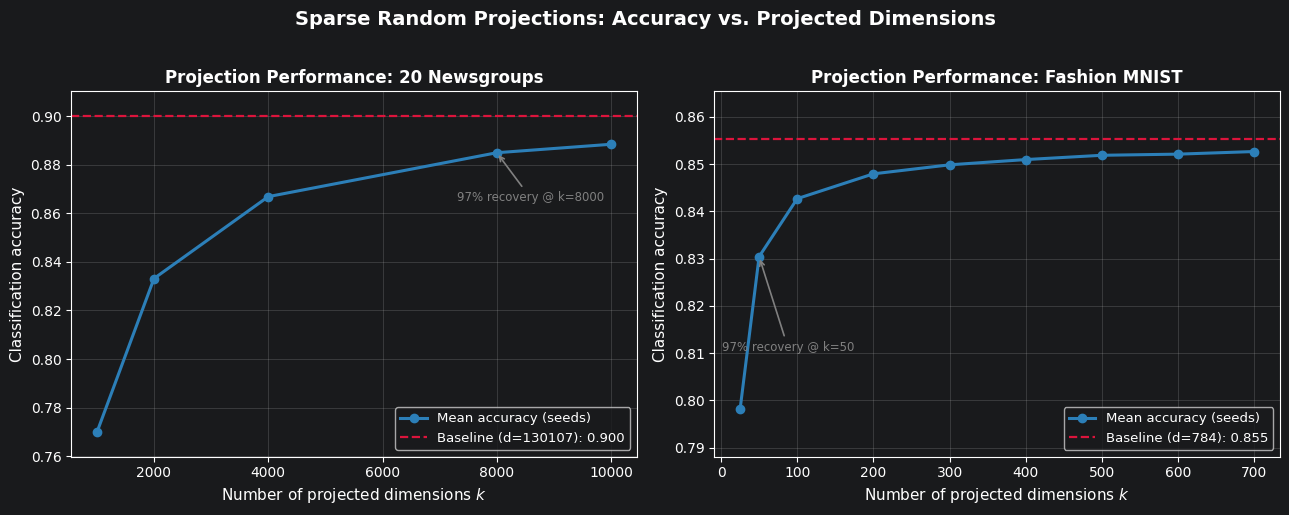

In [82]:
# Initialize plotting side-by-side
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Sparse Random Projections: Accuracy vs. Projected Dimensions",
             fontsize=14, fontweight='bold', y=1.02)

# Plot 20 Newsgroups results
plot_projection_performance(
    axes[0], dims_news, projected_accuracies, baseline_news, newsgroups.data.shape[1],
    title='Projection Performance: 20 Newsgroups'
)

# Plot Fashion MNIST results
plot_projection_performance(
    axes[1], dims_fmnist, projected_accuracies_fmnist, baseline_fmnist, X_train_f_flat.shape[1],
    title='Projection Performance: Fashion MNIST'
)

plt.tight_layout()
plt.show()

# 3. The Final "Take-Home Message"

Based on our experiments applying Sparse Random Projections to the 20 Newsgroups (sparse text) and Fashion-MNIST (dense image) datasets, we can draw several key conclusions:

 *   **Massive Dimensionality Reduction is Highly Data-Dependent:** While the technique allows us to discard a vast majority of original features, its success depends heavily on the dataset's nature. For Fashion MNIST (images embedded in Euclidean space, d=784), projecting down to just a few hundred dimensions yields classification accuracy nearly identical to the baseline. However, for 20 Newsgroups (sparse TF-IDF text, d=130,107), accuracy struggles to fully recover to the baseline even at much higher dimensions. This demonstrates that random projections are exceptionally suited for data where Euclidean distance is a natural similarity measure, but less optimal for non-Euclidean spaces like text.

 *   **The Johnson-Lindenstrauss Lemma is Conservative in Practice:** The JL Lemma guarantees that pairwise Euclidean distances are preserved at a specific minimum dimension k. In our notebook, the calculated JL bounds were 8437 for Newsgroups and 627 for Fashion MNIST. In practice, however, we observe a "steep rise followed by a smooth plateau," where distance-based classifiers (like KNN) achieve near-baseline performance at a k significantly lower than the theoretical bound suggests.

 *   **The Importance of Ensembling:** Because the projection matrix is generated randomly, a single run can be "lucky" or "unlucky" at preserving specific class boundaries, resulting in zig-zag variance across dimensions. By ensembling the results (averaging over 10–15 random seeds), we successfully collapsed this variance. This smoothing provides a reliable, stable view of how classification performance scales with the number of retained features.

## Overall Conclusion:
Sparse Random Projections offer a computationally cheap and memory-efficient way to defeat the Curse of Dimensionality. However, for ML pipelines, it is best applied to high-dimensional datasets where Euclidean distance is relevant (like images). For sparse, non-Euclidean data like text, alternative reduction methods or native sparse representations may be more appropriate.